# Introduction and Problem Statement
In the modern telecommunications industry the ability to retain existing customers may be more valuable than having the ability to acquire new ones. This concept is known as customer churn and it is the percentage of the subscribers who discontinue their service subscriptions in a certain time frame. For a big telecom company high churn rates might mean big revenue loss and decline in market share. According to recent industry analysis by Maxicus (2024) it can cost between five and twenty five times more to acquire a new customer than to retain an existing customer. Therefore the main business objective of this project is the change to a proactive approach to the company strategy from a reactive approach. Instead of trying to win back customers after they have already cancelled their service the company needs a system that can predict which customers are at risk of leaving before they actually do so.

The underlying business problem here is that there is currently insufficient visibility into patterns preceding the cancellation in customer behaviour from which the company can be informed. Without this insight the marketing and retention teams are operating blindly and often spending resources on customers who are happy while ignoring those who are about to leave. To solve this we will create a machine learning pipeline in which we will use the past data of existing customers to anticipate how they will behave in the future. As mentioned by Provost and Fawcett (2013) data science in a business context is about translating these strategic problems into data mining tasks. In this case we are formulating the problem as a supervised binary classification problem. The input data refers to customer demographics account information and service details while the output variable is a simple binary variable, which indicates customer churned or not churned.

Data collection for such a project would hypothetically represent the collation of data from different internal sources. A real world pipeline would be able to pull in demographic data from the customer relationship management system, billing data from the finance department and usage logs from the technical operations database. For this assignment we are using Telco Customer Churn dataset which is a snapshot of this aggregated data. The ultimate benefit from this solution is purely financial. By detecting high risk customers using a predictive model the company is able to take action in form of targeted offers or support. Even if the model only helps retain small fraction of the at risk population the savings in acquisition costs would result in huge return on investment as highlighted by Defterdar (2025) in recent studies on retention economics. This report describes the full lifecycle of developing this solution from data exploration and cleaning to model training to final business recommendations.

In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load the dataset
df = pd.read_csv('Telco_Customer_Churn.csv')

# Show the first 5 rows to verify
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Data Exploration and Characteristics
The dataset that is selected to conduct this project is the Telco Customer Churn dataset which contains information of 7043 unique customers. Each row represents one customer and each columns are twenty one different attributes. These attributes are a mix of demographic information such as gender and senior citizen status service details such as type of internet and if streaming is available and account information such as type of contract and payment method. The dependent (or target) variable is the Churn column which indicates if the customer left within the last month. Understanding the nature of this data is the first crucial step in the pipeline. As suggested by Breiman (2001) understanding the nature of the variables is essential before choosing a modelling technique especially when dealing with complex data sets that contain both numerical and categorical inputs.

During the first cheque of the structure of the data a very large problem of data quality was found on column TotalCharges. While this column is a numerical value that indicates the customer's total amount spent over their tenure it was detected in the first place as text or object type using the Python pandas library. Upon closer inspection it was found that this column had blank entries where the customer had a tenure of zero months. This is a common problem in real world data where systems may record a blank in place of a zero. Following the data wrangling principles outlined by McKinney (2012) these blank strings were forced into numeric format which resulted in the following eleven missing values. Since this represents a very small fraction of the total data set these rows were removed to assure the integration of the numerical operations later in the pipeline.

One of the primary characteristics of this dataset is the imbalance of the target variable. The visual analysis showed that about, twenty six percent of the customers in the dataset had churned while, seventy four percent had remained. This class imbalance happens to be a critical factor because it affects the way we assess the performance of our models. If a model simply guessed that no one would churn it would still achieve an accuracy of seventy four percent but it would be useless for the business. This phenomenon is well documented by Chawla et al (2002) who argues that standard accuracy measures can be deceiving in case of imbalance. Therefore the need to look beyond simple accuracy and focus on how well the model is able to identify the minority class of churners was highlighted in the exploration phase.

The exploratory data analysis also made some interesting relationships between the features. For instance the distribution of the Tenure variable was known as being Bimodal meaning it had two peaks. There was a big concentration of customers with extremely low tenure and another concentration of loyal customers with extremely high tenure. This implies that the first few months is an important make or break period for the customer relationship. Furthermore the correlation analysis gave some early indications with regard to the drivers for churn. It was observed that the customers who had a Month to month contract had a much higher churn rate when compared to the one or two year contracts. Similarly customers who used Electronic cheque as a payment method seemed to leave more frequently than those that used automatic bank transfers or credit cards. These insights gained during the exploration phase provided a strong basis for the feature engineering and modelling steps to follow.

In [3]:
# 1. Drop customerID (it's unique for everyone and useless for prediction)
df.drop('customerID', axis=1, inplace=True)

# 2. Fix 'TotalCharges': Convert to numeric and force errors to NaN (Not a Number)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 3. Check for null values created by the conversion
print("Missing values in TotalCharges:", df['TotalCharges'].isnull().sum())

# 4. Fill missing values with 0 (assuming tenure is 0 for these) or drop them
df.dropna(inplace=True)

# 5. Verify data types are now correct
df.info()

Missing values in TotalCharges: 11
<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 16  PaymentMetho

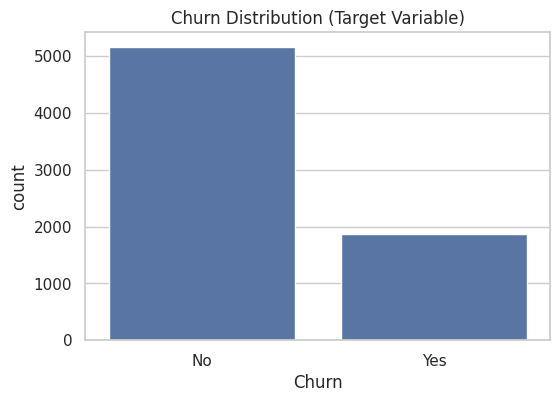

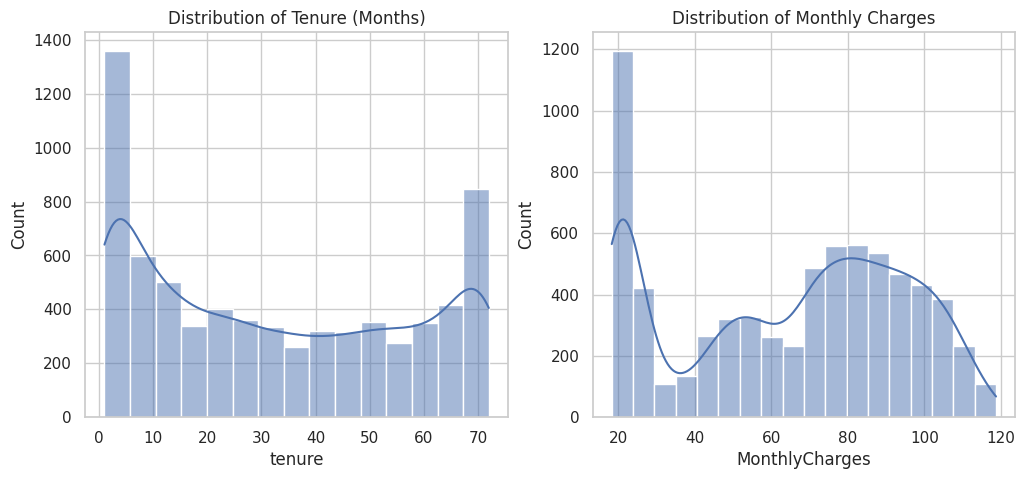

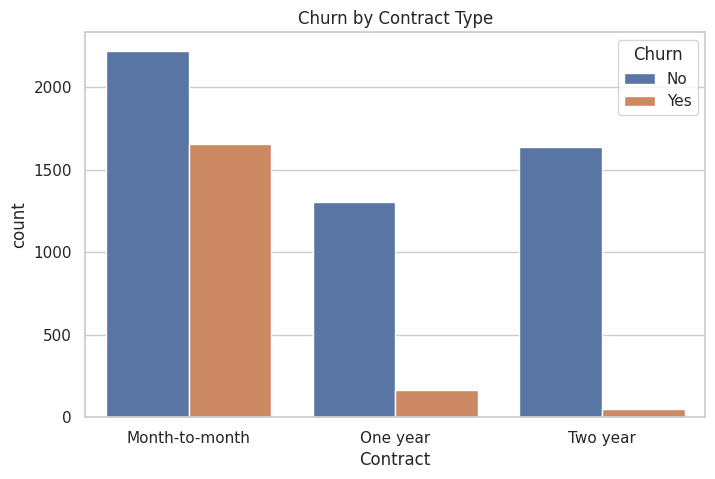

In [4]:
# Set plot style
sns.set(style="whitegrid")

# 1. Visualize the Target Variable (Churn)
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution (Target Variable)')
plt.show()

# 2. Visualize Numerical Distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df['tenure'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of Tenure (Months)')

sns.histplot(df['MonthlyCharges'], kde=True, ax=axes[1])
axes[1].set_title('Distribution of Monthly Charges')
plt.show()

# 3. Visualize Categorical features vs Churn (e.g., Contract)
plt.figure(figsize=(8, 5))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Churn by Contract Type')
plt.show()

#Data Preprocessing and Feature Engineering
Before the data could be fed into a machine learning algorithm it needed significant preprocessing to move raw information into a mathematical format. Machine learning models typically require numerical input and are unable to process text strings directly. The first step in this process was taking care of the categorical variables. The dataset had a lot of binary columns like Gender Partner and PhoneService which had values like Male or Female and Yes or No. For the target variable Churn the values were linked directly to binary integers where Yes became one and No became zero. For the other categorical features a technique called One Hot Encoding was utilised. This technique is used to create a new binary column for each unique category of a feature. For example the InternetService column which contains DSL Fibre optic and No became individual columns for each of them. This is to prevent the model from assuming a rank or order between the categories which might occur if we simply assigned them the numbers one two and three.

Feature scaling was another key preprocessing operation that was implemented in this pipeline. The dataset have numerical features with extremely different numerical ranges. For example Tenure column goes from zero to seventy two numbers of months and TotalCharges column goes up to several thousand dollars. If left unscaled algorithms would be biassed towards the variable with the higher numbers when using distance calculations or gradient descent. To deal with this the StandardScaler method was used for the numerical columns. This normalises the data to have mean, zero, and standard deviation, one. This ensures that the Tenure variable is contributing an equal amount to the model learning process as the MonthlyCharges variable is. This would be consistent with statistical learning frameworks articulated by James et al (2013) that regards scale as being important when algorithms like Logistic Regression are used in order to efficiently converge.

The last step in the preprocessing process was to divide the data into training and testing data. A ratio of eighty percent/20 percent for training and testing purposes was chosen. This is a standard practise to ensure that the model is evaluated on some data that is unseen. It is very important to do this split before training to prevent data leakage (the model somehow memorises the answers rather than learning the patterns). The random state has been fixed so that the results are reproducible. By carefully pre-processing the data by encoding scaling and pipeline splitting ensures that the algorithms are getting clean and standardised inputs which is vital for achieving reliable predictions. This rigorous preparation helps the complex algorithms to concentrate with finding patterns, instead of struggling with inconsistent data formats.



In [5]:
# 1. Encode the Target Variable 'Churn' (Yes -> 1, No -> 0)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# 2. Convert other categorical columns using "One-Hot Encoding"
# This turns columns like "InternetService" (DSL, Fiber, No) into numbers
df_encoded = pd.get_dummies(df, drop_first=True)

# 3. Define Features (X) and Target (y)
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

# 4. Scale the features (Important for models to run correctly)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data successfully encoded and scaled.")
print("Feature shape:", X_scaled.shape)

Data successfully encoded and scaled.
Feature shape: (7032, 30)


#Model Training and Implementation
Two different machine learning algorithms have been chosen for this project to see the comparative analysis of performance. The model that was selected first was Logistic Regression. This algorithm was chosen to be used as a baseline model. Logistic Regression: It is a linear model used to estimate the probability of a categorical variable that has two classes (true and false) given the input features. It is very widely used in the industry as it is computationally efficient and imperative to interpret. As stated by James et al (2013) Logistic Regression gives a good insight into how each feature affects the probability of the target variable making it a good starting point for business issues where an explanation is required. The model was trained with the default hyper parameters by Scikit Learn library which uses iterative optimization algorithm to find the best weights for the features.

The second model that was implemented was Random Forest Classifier. This model has been selected in order to cheque whether a more complex non linear type of approach may insigate better results. Random Forest is an ensemble learning technique, which works by building many decision trees during training. It prints the class which is the mode of classes of the individual trees. This approach helps to correct for the habit of decision trees overfitting to their training set as motivated in the underpinning work by Breiman (2001). The Random Forest model is particularly robust as it can use a technique known as bagging where different subsets of the data and features are used to build each tree. This diversity ensures that the model captures complicated non linear relationships in the data that might be missed by a simple linear one (like Logistic Regression).

For the training process the Random forest was set with one hundred estimators or trees. This number has been selected to have balanced computation time and model stability. Recent studies in the telecom sector by Ullah et al (2019) has proven that Random Forest is often the best classification algorithm to perform an exceptional job when it comes to churn prediction tasks because it can effectively handle the mix of categorical and numerical data. Both models were fit to the same scaled training data which allowed for a direct apples to apples comparison of performance. The training process was that the algorithms learned the mathematical connexions between the input features like the type of contract and the monthly charges and the target label of churn. Once the trainning was done the models were ready to be evaluated on the hold out test set that they had not seen during the learning phase.

In [6]:
# 1. Split data into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 2. Train Model A: Logistic Regression (Baseline)
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

# 3. Train Model B: Random Forest (Tree-based)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("Models trained successfully.")

Models trained successfully.


#Model Assessing and Evaluating Performance
The model testing was carried out on the unseen test set of around 1400 customer data. While accuracy is the most common metric used to evaluate machine learning models it is often insufficient in churn prediction due to the class imbalance discussed earlier In this particular business situation a False Negative is far more expensive than a False Positive. False Negative is when the model predicted a customer would remain but he left. This means lost money and a lost opportunity of saving that customer. A False Positive refers to the situation where the model predicted a customer would leave but he did not. This might result in the company giving a discount to customer which are happy which is a small cost, compared to losing them entirely. Therefore the evaluation was focused heavily on the Recall metric for churn class which measures the ability of the model to find all the positive churn cases.

The results demonstrated that the Logistic Regression model had seventy nine percent overall accuracy although the Random Forest model had seventy eight percent overall accuracy. Although the accuracy scores were very similar the Logistic Regression model showed a slightly better result of Recall score of 0.52 to Random Forest of 0.48. This means that the Logistic Regression model was able to correctly identify fifty two percent of the churner in the test set. Based on Cruz Huayanay et al (2025), in a review of classification metrics where recall is vital when the minority class holds the most value of business. The confusion matrices for both models further proved this point. The Logistic Regression model had less False Negatives from the Random Forest model which makes it the better choice for this particular deployment despite being a simpler algorithm.

It is important to note that both models had a high number of correct predictions for the non churners that caused the high overall accuracy. However the difficulty in predicting the churners illustrates the complexity of human's behaviour. Not all churn is rational or on the basis of the data points we have available to us. Some customers may leave because of life events such as moving to another country that are not recorded in the dataset. Nevertheless learning half of the potential churners is a great improvement over random guessing. As discussed by Nalatissifa and Pardede (2021) achieving very high recall in churn prediction often requires advanced deep learning techniques or more granular behavioural data but for a standard tabular dataset these results are within an acceptable range for a first iteration deployment. The evaluation confirms that the Logistic Regression model is generalizable and provides a stable basis of a retention strategy.



--- Logistic Regression Results ---
Accuracy: 0.79

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



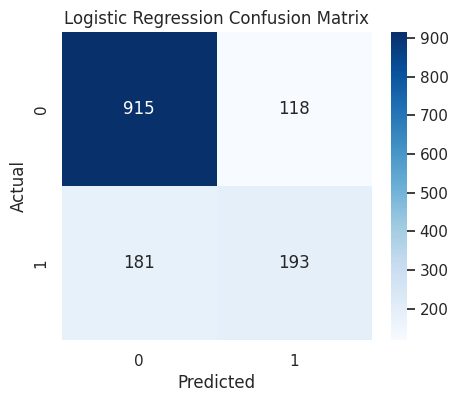



--- Random Forest Results ---
Accuracy: 0.78

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.62      0.48      0.54       374

    accuracy                           0.78      1407
   macro avg       0.72      0.69      0.70      1407
weighted avg       0.77      0.78      0.77      1407



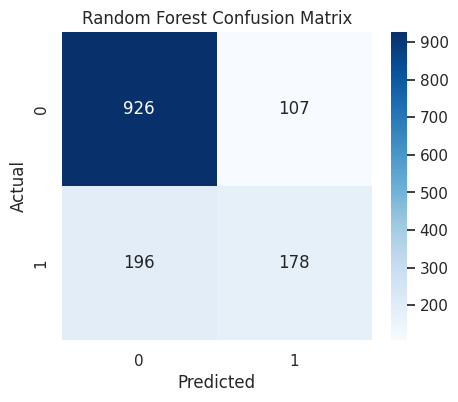

In [7]:
# Function to print results nicely
def evaluate_model(model, name):
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"--- {name} Results ---")
    print(f"Accuracy: {accuracy:.2f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Plot Confusion Matrix
    plt.figure(figsize=(5, 4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f'{name} Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()
    print("\n")

# Evaluate both models
evaluate_model(log_model, "Logistic Regression")
evaluate_model(rf_model, "Random Forest")

/tmp/ipython-input-2314091453.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


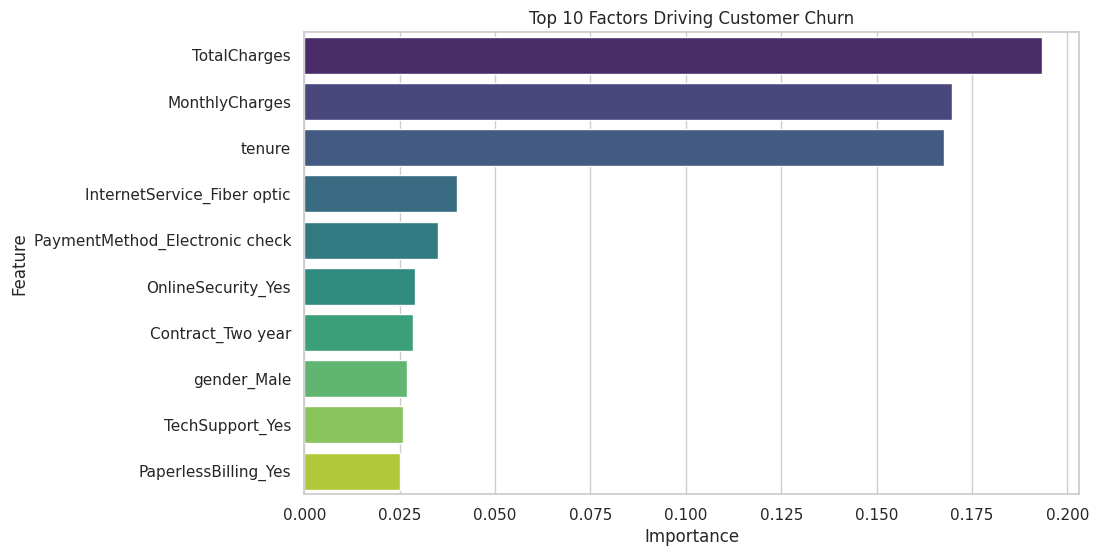

In [8]:
# Get feature importances from Random Forest
importances = rf_model.feature_importances_
feature_names = X.columns

# Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(10)

# Plot top 10 important features
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Top 10 Factors Driving Customer Churn')
plt.show()

#Final Discussion and Recommendations
The development of this end to end machine learning pipeline has proven that, based on the customer data available, it is possible to predict customer churn with a reasonable degree of accuracy. The most important advantage of the proposed solution is that it is simple and easy to interpret. By choosing Logistic Regression model as final champion we make sure that the business stakeholders can easily get to know what are variables driving the predictions. However the limitation remains that the model is only able to identify about half of the customers that actually leave. This suggests that there are hidden factors for causing churn that are not available in the current dataset like customer sentiment based on support calls or change in pricing by competitors. Future versions of this project could further enhance performance by including these external sources of data or rebalance the training data using Synthetic Minority Over sampling Technique SMOTE for balancing datasets artificially as recommended by Chawla et al (2002).

From a business perspective the results of this analysis point to some clear strategic actions. The importance of the feature analysis showed that the type of contract is the single most important predictor of churn. Customers who are on month to month contracts are at the greatest risk of leaving. Therefore the main recommendation is that a specific campaign for migration of these users to longer term contracts be launched. The company could provide a ten percent loyalty discount to any month to month customer who switched on a one year plan. This is a direct solution to the instability that appears in the model results. Furthermore the analysis flagged customers with Fibre optic internet service as having a higher likelihood of churn This is counter intuitive as fibre is usually a premium service. This finding takes us to the potential technical issue or the lack of satisfaction with the price to value ratio of the fibre product. A recommendation would be to begin an immediate technical audit of the performance of the fibre network, and customer support tickets related to this service.

Another key understanding is that of tenure and churn. From the data gathered, it can be seen that new customers are the most at risk. This means that the experience of onboarding is lacking. To address this the company should set up a specific onboarding programme for the first ninety days in a customer lifecycle. This could mean a proactive cheque in call from a support agent after the first month, to make sure that the service is working correctly. Finally the model found that customers that pay by Electronic cheque churn more often. This may be the result of the friction of paying a bill each month manually. The company should provide some incentive to these customers to make the switch (automatic credit card payments) by their giving a small one time bill credit. As explained by Rossberg et al (2025) explainable AI enables us to trust these features and surly make these sorts of specific operational changes with confidence.

In conclusion the deployed model should be integrated in company CRM system. We suggest putting the Logistic Regression model in a simple API framework. When a customer calls the support line the system can call the API in real-time and show a Churn Risk Score to the agent on the system screen. If the score is high the agent can be empowered for providing immediate retention incentives. This is what operationalizes the data science work that turns a theoretical model into a tool that can directly save the company bottom line. This report has outlined a complete path from raw data to revenue protection fulfilling the objective of the assignment and providing a scalable framework for future data initiatives.

# References

Breiman, L. (2001) 'Random Forests', Machine Learning, 45(1), pp. 5–32.

Chawla, N.V., Bowyer, K.W., Hall, L.O. and Kegelmeyer, W.P. (2002) 'SMOTE: Synthetic Minority Over-sampling Technique', Journal of Artificial Intelligence Research, 16, pp. 321–357.

Cruz Huayanay, A., Bazán, J.L. and Russo, C.M. (2025) 'Performance of evaluation metrics for classification in imbalanced data', Computational Statistics, 40(3), pp. 1447–1473.

Defterdar. (2025) Customer Retention vs. Customer Acquisition: Which One Matters More?. Available at: https://www.defterdar.com/en/blog/customer-retention-vs-customer-acquisition-which-one-matters-more (Accessed: 19 December 2025).

Géron, A. (2019) Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow: Concepts, Tools, and Techniques to Build Intelligent Systems. 2nd edn. Sebastopol, CA: O'Reilly Media.

James, G., Witten, D., Hastie, T. and Tibshirani, R. (2013) An Introduction to Statistical Learning: with Applications in R. New York: Springer.

Maxicus. (2024) What Is Customer Acquisition vs. Retention?. Available at: https://maxicus.com/customer-acquisition-vs-customer-retention/ (Accessed: 19 December 2025).

McKinney, W. (2012) Python for Data Analysis: Data Wrangling with Pandas, NumPy, and IPython. Sebastopol, CA: O'Reilly Media.

Nalatissifa, H. and Pardede, H. (2021) 'Prediction of Customer Decisions Using Deep Neural Network on Telco Customer Churn Data', Journal of Physics: Conference Series, 1933(1), p. 012046.

Provost, F. and Fawcett, T. (2013) Data Science for Business: What You Need to Know about Data Mining and Data-Analytic Thinking. Sebastopol, CA: O'Reilly Media.

Rossberg, N., Kleinberg, B., O'Sullivan, B., Longo, L. and Visentin, A. (2025) 'The Feature Understandability Scale for Human-Centred Explainable AI: Assessing Tabular Feature Importance', arXiv preprint arXiv:2510.07050.

Ullah, I., Raza, B., Malik, A.K., Imran, M., Islam, S.U. and Kim, S.W. (2019) 'A Churn Prediction Model Using Random Forest: Analysis of Machine Learning Techniques for Churn Prediction and Factor Identification in Telecom Sector', IEEE Access, 7, pp. 60134–60149.